In [1]:
# google colab data management
import os.path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    _home = 'drive/MyDrive/'
except ImportError:
    _home = '~'
finally:
    data_root = os.path.join(_home, '.pytorch')

print(data_root)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
drive/MyDrive/.pytorch


In [2]:
pip install torch torchvision pydicom pandas matplotlib opencv-python

In [3]:
import os
import cv2
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import functional as F

from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

In [4]:
IMAGE_SIZE = 384

BATCH_SIZE = 4
EPOCHS = 40

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CSV_PATH = '/content/drive/MyDrive/DeepLesion_Lung/DL_info.csv'

IMAGE_ROOT = '/content/drive/MyDrive/DeepLesion_Lung/images_png'

NUM_CLASSES = 2

In [5]:
def window_image(img, window_center=-600, window_width=1500):
    img = img.astype(np.float32)
    img = img - 32768.0          # convert to true HU
    low  = window_center - window_width / 2   # -1350
    high = window_center + window_width / 2   #   150
    img  = np.clip(img, low, high)
    img  = (img - low) / (high - low)         # [0, 1]
    return img

In [7]:
def load_3channel_image(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

    def read_slice(p):

        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
        if img is None:
            return None

        img = img.astype(np.float32)
        return window_image(img)

    center = read_slice(path)
    if center is None:
        raise ValueError(f"Could not read: {path}")

    base      = os.path.basename(path)
    slice_idx = int(base.split('_')[-1].replace('.png', ''))

    prev_path = path.replace(f"{slice_idx:03d}.png", f"{max(slice_idx-1,0):03d}.png")
    next_path = path.replace(f"{slice_idx:03d}.png", f"{slice_idx+1:03d}.png")

    prev = read_slice(prev_path) if os.path.exists(prev_path) else center.copy()
    nxt  = read_slice(next_path) if os.path.exists(next_path) else center.copy()

    image = np.stack([prev, center, nxt], axis=0)  # (3, H, W), float32, [0,1]
    return image

In [10]:
class DeepLesionDataset(Dataset):

    def __init__(self, dataframe, mode='train'):
        self.df   = dataframe.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(IMAGE_ROOT, row["File_name"])
        image = load_3channel_image(img_path)   # (3, H, W), float32, [0,1]

        h0, w0 = image.shape[1], image.shape[2]

        # Augmentation
        if self.mode == 'train':

            if random.random() > 0.5:
                image = image[:, :, ::-1].copy()
                flip_x = True
            else:
                flip_x = False

            center = image[1]
            center = np.clip(center * random.uniform(0.8, 1.2)
                            + random.uniform(-0.05, 0.05), 0, 1)
            image[1] = center
        else:
            flip_x = False

        # Resize
        image = np.transpose(image, (1, 2, 0))
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        image = np.transpose(image, (2, 0, 1))

        scale_x = IMAGE_SIZE / w0
        scale_y = IMAGE_SIZE / h0

        x1, y1, x2, y2 = map(float, row["Bounding_boxes"].split(','))
        x1 *= scale_x;  x2 *= scale_x
        y1 *= scale_y;  y2 *= scale_y

        if flip_x:
            x1, x2 = IMAGE_SIZE - x2, IMAGE_SIZE - x1

        boxes  = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)
        labels = torch.tensor([1], dtype=torch.int64)

        image = torch.tensor(image, dtype=torch.float32)
        return image, {"boxes": boxes, "labels": labels}

In [12]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [13]:
def get_model():

    backbone = resnet_fpn_backbone(
        backbone_name='resnet50',
        weights='DEFAULT'
    )

    anchor_generator = AnchorGenerator(
        sizes=((8,), (16,), (32,), (64,), (128,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5
    )

    model = FasterRCNN(
        backbone=backbone,
        num_classes=NUM_CLASSES,
        rpn_anchor_generator=anchor_generator
    )

    return model

In [14]:
df = pd.read_csv(CSV_PATH)

In [15]:
# df.head()

In [16]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

lung_info = df[
    df["Coarse_lesion_type"] == 5
].copy()

patients = lung_info["Patient_index"].unique()

random.shuffle(patients)

# 80/10/ 10split
n_total = len(patients)

n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)

train_patients = patients[:n_train]

val_patients = patients[
    n_train:n_train+n_val
]

test_patients = patients[
    n_train+n_val:
]


train_df = lung_info[
    lung_info["Patient_index"].isin(train_patients)
].reset_index(drop=True)

val_df = lung_info[
    lung_info["Patient_index"].isin(val_patients)
].reset_index(drop=True)

test_df = lung_info[
    lung_info["Patient_index"].isin(test_patients)
].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 1927
Val: 255
Test: 212


In [17]:
train_dataset = DeepLesionDataset(train_df, mode='train')
val_dataset = DeepLesionDataset(val_df, mode='val')
test_dataset = DeepLesionDataset(test_df, mode='test')

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [18]:
model = get_model()

model.to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_58157/3484976733.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [19]:
SAVE_DIR = '/content/drive/MyDrive/DeepLesion_Lung/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

patience = 15
epochs_no_improvement = 0
best_val_loss = float('inf')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    pbar = tqdm(train_loader)
    for images, targets in pbar:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += losses.item()
        pbar.set_description(f"Epoch {epoch+1} Loss: {losses.item():.4f}")

    train_loss = running_loss / len(train_loader)

    model.train()
    val_loss = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images  = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            with torch.amp.autocast('cuda'):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()
    val_loss /= len(val_loader)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:>3} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {current_lr:.2e}")
    # print(f"Epoch {epoch+1:>3} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),
                   f"{SAVE_DIR}/best_model_epoch{epoch+1}.pth")
        print(f"  ✅ Saved (val={val_loss:.4f})")
    else:
      epochs_no_improvement += 1
      if epochs_no_improvement == patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

  0%|          | 0/482 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1 Loss: 0.1093: 100%|██████████| 482/482 [03:53<00:00,  2.06it/s]


Epoch   1 | Train: 0.0798 | Val: 0.0639 | LR: 4.99e-05
  ✅ Saved (val=0.0639)


Epoch 2 Loss: 0.0867: 100%|██████████| 482/482 [03:52<00:00,  2.07it/s]


Epoch   2 | Train: 0.0615 | Val: 0.0618 | LR: 4.97e-05
  ✅ Saved (val=0.0618)


Epoch 3 Loss: 0.0698: 100%|██████████| 482/482 [03:51<00:00,  2.08it/s]


...

Epoch  19 | Train: 0.0170 | Val: 0.0750 | LR: 2.74e-05


Epoch 20 Loss: 0.0339: 100%|██████████| 482/482 [03:44<00:00,  2.15it/s]


Epoch  20 | Train: 0.0156 | Val: 0.0682 | LR: 2.55e-05


Epoch 21 Loss: 0.0157: 100%|██████████| 482/482 [03:43<00:00,  2.15it/s]


Epoch  21 | Train: 0.0143 | Val: 0.0645 | LR: 2.36e-05
Early stopping at epoch 21


In [23]:
# SAVE_DIR = '/content/drive/MyDrive/DeepLesion_Lung/checkpoints'

# checkpoint_path = f"{SAVE_DIR}/best_model_epoch6.pth"

# model = get_model()  # recreate architecture
# model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
# model.to(DEVICE)
# model.eval()

In [24]:
model.eval()

images, targets = next(iter(val_loader))

images_gpu = [
    img.to(DEVICE)
    for img in images
]

with torch.no_grad():

    predictions = model(images_gpu)

In [34]:
from torchvision.ops import box_iou

SAVE_DIR = '/content/drive/MyDrive/DeepLesion_Lung/checkpoints'
model = get_model()
model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model_epoch11.pth",
                                  map_location=DEVICE))
model.to(DEVICE)
model.eval()

thresholds = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results = {t: {'tp': 0, 'fp': 0, 'fn': 0} for t in thresholds}

with torch.no_grad():
    for images, targets in val_loader:
        images_gpu = [img.to(DEVICE) for img in images]
        preds = model(images_gpu)

        for pred, target in zip(preds, targets):
            gt_boxes = target['boxes']

            for threshold in thresholds:
                keep       = pred['scores'] >= threshold
                pred_boxes = pred['boxes'][keep].cpu()

                if len(pred_boxes) == 0:
                    results[threshold]['fn'] += len(gt_boxes)
                    continue

                # Per GT box: matched if any pred has IoU > 0.1
                for gt_box in gt_boxes:
                    ious = box_iou(pred_boxes, gt_box.unsqueeze(0)).squeeze(1)
                    if ious.max() >= 0.1:
                        results[threshold]['tp'] += 1
                    else:
                        results[threshold]['fn'] += 1

                # Per pred box: FP if no GT match
                for pb in pred_boxes:
                    ious = box_iou(pb.unsqueeze(0), gt_boxes).squeeze(0)
                    if ious.max() < 0.1:
                        results[threshold]['fp'] += 1

print(f"\n{'Thresh':>7} | {'Precision':>10} | {'Recall':>8} | {'F1':>8} | {'TP':>5} | {'FP':>5} | {'FN':>5}")
print("-" * 65)
for t in thresholds:
    tp, fp, fn = results[t]['tp'], results[t]['fp'], results[t]['fn']
    prec   = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1     = 2 * prec * recall / (prec + recall + 1e-6)
    print(f"{t:>7.2f} | {prec:>10.3f} | {recall:>8.3f} | {f1:>8.3f} | {tp:>5} | {fp:>5} | {fn:>5}")


 Thresh |  Precision |   Recall |       F1 |    TP |    FP |    FN
-----------------------------------------------------------------
   0.05 |      0.273 |    0.914 |    0.420 |   233 |   622 |    22
   0.10 |      0.331 |    0.882 |    0.481 |   225 |   455 |    30
   0.20 |      0.388 |    0.863 |    0.535 |   220 |   347 |    35
   0.30 |      0.447 |    0.859 |    0.588 |   219 |   271 |    36
   0.40 |      0.486 |    0.847 |    0.618 |   216 |   228 |    39
   0.50 |      0.524 |    0.827 |    0.641 |   211 |   192 |    44
   0.60 |      0.558 |    0.808 |    0.660 |   206 |   163 |    49
   0.70 |      0.605 |    0.788 |    0.685 |   201 |   131 |    54


In [33]:
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'model_config': {
#         'backbone': 'resnet50',
#         'num_classes': 2,
#         'image_size': IMAGE_SIZE,
#         'anchor_sizes': ((8,), (16,), (32,), (64,), (128,)),
#         'anchor_ratios': ((0.5, 1.0, 2.0),) * 5,
#     },
#     'score_threshold': 0.3,
#     'nms_threshold': 0.3,
#     'training_info': {
#         'epochs': EPOCHS,
#         'best_val_loss': best_val_loss,
#         'dataset': 'DeepLesion lung (Coarse_lesion_type=5)',
#     }
# }, f"{SAVE_DIR}/deployment_model.pth")
# print("Deployment artifact saved.")

Deployment artifact saved.


In [35]:
# model.eval()
# model.cpu()

# scripted = torch.jit.script(model)
# scripted.save(f"{SAVE_DIR}/model_scripted.pt")
# print("TorchScript model saved.")

# loaded = torch.jit.load(f"{SAVE_DIR}/model_scripted.pt")
# loaded.eval()

TorchScript model saved.
TorchScript verification passed.
Output keys: dict_keys([])


code/__torch__/torchvision/models/detection/faster_rcnn.py:103: UserWarning: RCNN always returns a (Losses, Detections) tuple in scripting


Total predictions before threshold : 2
Score range: 0.0870 – 0.9967
GT box: [164.022   216.49875 176.6595  232.806  ]


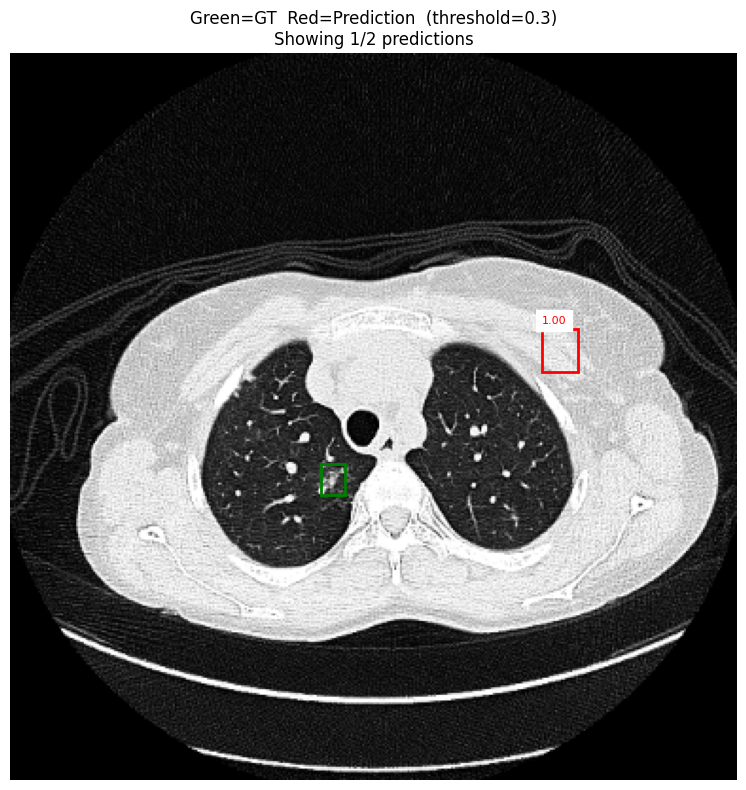

In [31]:
IDX = 0

img_np = images[IDX].cpu().numpy()[1]              # center slice, (H, W)

pred_boxes = predictions[IDX]["boxes"].cpu().numpy()
scores     = predictions[IDX]["scores"].cpu().numpy()
gt_box     = targets[IDX]["boxes"][0].numpy()

print(f"Total predictions before threshold : {len(scores)}")
print(f"Score range: {scores.min():.4f} – {scores.max():.4f}" if len(scores) > 0 else "No predictions at all")
print(f"GT box: {gt_box}")

plt.figure(figsize=(8, 8))
plt.imshow(img_np, cmap='gray')

# Ground truth — green
x1, y1, x2, y2 = gt_box
plt.gca().add_patch(plt.Rectangle(
    (x1, y1), x2-x1, y2-y1,
    fill=False, edgecolor='green', linewidth=2, label='GT'
))

# Predictions — red
SCORE_THRESHOLD = 0.3
plotted = 0
for box, score in zip(pred_boxes, scores):
    if score < SCORE_THRESHOLD:
        continue
    x1, y1, x2, y2 = box
    plt.gca().add_patch(plt.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        fill=False, edgecolor='red', linewidth=2
    ))
    plt.text(x1, y1-3, f"{score:.2f}",
             color='red', fontsize=8, backgroundcolor='white')
    plotted += 1

plt.title(f"Green=GT  Red=Prediction  (threshold={SCORE_THRESHOLD})\n"
          f"Showing {plotted}/{len(scores)} predictions")
plt.axis('off')
plt.tight_layout()
plt.show()